In [2]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Config - change these paths to where you put the files
ANIME_PATH = "data/anime.csv"
RATINGS_PATH = "data/rating_complete.csv"

# Filtering thresholds - we will tune these
MIN_USER_RATINGS = 50  # users must have rated at least this many anime
MIN_ANIME_RATINGS = 100  # anime must have been rated by at least this many users

In [3]:
anime_df = pd.read_csv(ANIME_PATH)

print("Shape:", anime_df.shape)
print("\nColumns:", anime_df.columns.tolist())
print("\nFirst row:")
print(anime_df.iloc[0])
print("\nMissing values:")
print(anime_df.isnull().sum())
print("\nData types:")
print(anime_df.dtypes)

Shape: (17562, 35)

Columns: ['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name', 'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors', 'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6', 'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1']

First row:
MAL_ID                                                         1
Name                                                Cowboy Bebop
Score                                                       8.78
Genres           Action, Adventure, Comedy, Drama, Sci-Fi, Space
English name                                        Cowboy Bebop
Japanese name                                          カウボーイビバップ
Type                                                          TV
Episodes                                                      26
Aired                             

In [4]:
# Rename for clarity
anime_df = anime_df.rename(columns={"MAL_ID": "anime_id"})

# Handle 'Unknown' values - MAL uses the string 'Unknown' not NaN
anime_df.replace("Unknown", np.nan, inplace=True)

# Keep only relevant columns for our engine
keep_cols = [
    "anime_id",
    "Name",
    "Score",
    "Genres",
    "English name",
    "Type",
    "Episodes",
    "Studios",
    "Source",
    "Rating",
    "Members",
    "Favorites",
    "Completed",
    "Ranked",
    "Popularity",
]

anime_df = anime_df[keep_cols].copy()

# Clean Score column - it comes as object sometimes
anime_df["Score"] = pd.to_numeric(anime_df["Score"], errors="coerce")
anime_df["Episodes"] = pd.to_numeric(anime_df["Episodes"], errors="coerce")
anime_df["Members"] = pd.to_numeric(anime_df["Members"], errors="coerce")

# Fill name: prefer English name, fall back to Name
anime_df["display_name"] = anime_df["English name"].fillna(anime_df["Name"])

print("Anime cleaned shape:", anime_df.shape)
print("\nType distribution:")
print(anime_df["Type"].value_counts())
print("\nMissing after clean:")
print(anime_df[["Genres", "Studios", "Score", "Type"]].isnull().sum())

Anime cleaned shape: (17562, 16)

Type distribution:
Type
TV         4996
OVA        3894
Movie      3041
Special    2218
ONA        1907
Music      1469
Name: count, dtype: int64

Missing after clean:
Genres       63
Studios    7079
Score      5141
Type         37
dtype: int64


In [5]:
# Specify dtypes upfront - this alone saves ~60% RAM on this file
dtype_map = {"user_id": "int32", "anime_id": "int32", "rating": "int8"}

print("Loading rating_complete.csv... this takes a minute, file is ~1GB")
ratings_df = pd.read_csv(RATINGS_PATH, dtype=dtype_map)

print("Shape:", ratings_df.shape)
print("Memory usage:", ratings_df.memory_usage(deep=True).sum() / 1e6, "MB")
print("\nRating distribution:")
print(ratings_df["rating"].value_counts().sort_index())
print("\nUnique users:", ratings_df["user_id"].nunique())
print("Unique anime:", ratings_df["anime_id"].nunique())

Loading rating_complete.csv... this takes a minute, file is ~1GB
Shape: (57633278, 3)
Memory usage: 518.69963 MB

Rating distribution:
rating
1       333419
2       405556
3       696048
4      1455102
5      3436250
6      6849293
7     13325549
8     14642156
9      9773857
10     6716048
Name: count, dtype: int64

Unique users: 310059
Unique anime: 16872


In [6]:
# Step 1: filter users with at least MIN_USER_RATINGS
user_counts = ratings_df["user_id"].value_counts()
active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
ratings_filtered = ratings_df[ratings_df["user_id"].isin(active_users)].copy()
print(
    f"After user filter: {len(ratings_filtered):,} ratings, {ratings_filtered['user_id'].nunique():,} users"
)

# Step 2: filter anime with at least MIN_ANIME_RATINGS
anime_counts = ratings_filtered["anime_id"].value_counts()
popular_anime = anime_counts[anime_counts >= MIN_ANIME_RATINGS].index
ratings_filtered = ratings_filtered[
    ratings_filtered["anime_id"].isin(popular_anime)
].copy()
print(
    f"After anime filter: {len(ratings_filtered):,} ratings, {ratings_filtered['anime_id'].nunique():,} anime"
)

# Step 3: only keep anime that exist in anime_df (match both files)
valid_anime_ids = set(anime_df["anime_id"].unique())
ratings_filtered = ratings_filtered[
    ratings_filtered["anime_id"].isin(valid_anime_ids)
].copy()
print(f"After ID match: {len(ratings_filtered):,} ratings")

# Quick density check
n_users = ratings_filtered["user_id"].nunique()
n_anime = ratings_filtered["anime_id"].nunique()
density = len(ratings_filtered) / (n_users * n_anime)
print(f"\nMatrix: {n_users} users x {n_anime} anime")
print(f"Density: {density:.4%}  (anything above 0.5% is decent)")

After user filter: 55,857,448 ratings, 223,565 users
After anime filter: 55,647,215 ratings, 10,502 anime
After ID match: 55,647,215 ratings

Matrix: 223565 users x 10502 anime
Density: 2.3701%  (anything above 0.5% is decent)


In [7]:
# Create contiguous integer indices
unique_users = sorted(ratings_filtered["user_id"].unique())
unique_anime = sorted(ratings_filtered["anime_id"].unique())

user2idx = {u: i for i, u in enumerate(unique_users)}
anime2idx = {a: i for i, a in enumerate(unique_anime)}
idx2user = {i: u for u, i in user2idx.items()}
idx2anime = {i: a for a, i in anime2idx.items()}

ratings_filtered["user_idx"] = ratings_filtered["user_id"].map(user2idx)
ratings_filtered["anime_idx"] = ratings_filtered["anime_id"].map(anime2idx)

print(f"Matrix size: {len(unique_users)} x {len(unique_anime)}")

Matrix size: 223565 x 10502


In [8]:
train_df, test_df = train_test_split(
    ratings_filtered,
    test_size=0.2,
    random_state=42,
    stratify=None,  # too expensive to stratify on 57M, skip
)

print(f"Train: {len(train_df):,} ratings")
print(f"Test:  {len(test_df):,} ratings")

Train: 44,517,772 ratings
Test:  11,129,443 ratings


In [9]:
from scipy.sparse import csr_matrix

n_users = len(unique_users)
n_anime = len(unique_anime)

# Build the sparse matrix from training data only
train_matrix = csr_matrix(
    (
        train_df["rating"].values,
        (train_df["user_idx"].values, train_df["anime_idx"].values),
    ),
    shape=(n_users, n_anime),
    dtype=np.float32,
)

print("Sparse matrix shape:", train_matrix.shape)
print("Stored values (non-zero):", train_matrix.nnz)
print("Memory:", train_matrix.data.nbytes / 1e6, "MB")

Sparse matrix shape: (223565, 10502)
Stored values (non-zero): 44517772
Memory: 178.071088 MB


In [11]:
# CHUNK 9 REPLACEMENT - Richer content matrix
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

# These two lines were in old chunk 9, must keep them
anime_meta = anime_df[anime_df["anime_id"].isin(unique_anime)].copy()
anime_meta = anime_meta.set_index("anime_id").reindex(unique_anime).reset_index()

# rest of chunk 9 continues as is...
anime_meta_feat = anime_meta.copy()

# 1. GENRES
anime_meta_feat["genre_list"] = (
    anime_meta_feat["Genres"]
    .fillna("")
    .apply(lambda x: [g.strip() for g in x.split(",") if g.strip()])
)
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(anime_meta_feat["genre_list"])
print(f"Genres: {genre_matrix.shape[1]} features")

# 2. TYPE
type_dummies = pd.get_dummies(
    anime_meta_feat["Type"].fillna("Unknown"), prefix="type"
).values
print(f"Type: {type_dummies.shape[1]} features")

# 3. SOURCE
source_dummies = pd.get_dummies(
    anime_meta_feat["Source"].fillna("Unknown"), prefix="source"
).values
print(f"Source: {source_dummies.shape[1]} features")

# 4. AGE RATING
rating_dummies = pd.get_dummies(
    anime_meta_feat["Rating"].fillna("Unknown"), prefix="agerating"
).values
print(f"Age rating: {rating_dummies.shape[1]} features")


# 5. STUDIOS - top 50 only
def parse_studios(s):
    if not isinstance(s, str) or s.strip() == "":
        return []
    return [x.strip() for x in s.split(",") if x.strip()]


anime_meta_feat["studio_list"] = anime_meta_feat["Studios"].apply(parse_studios)
all_studios = [s for sl in anime_meta_feat["studio_list"] for s in sl]
top_studios = [s for s, _ in Counter(all_studios).most_common(50)]


def encode_studios(studio_list):
    return [s if s in top_studios else "Other" for s in studio_list] or ["Other"]


anime_meta_feat["studio_list_enc"] = anime_meta_feat["studio_list"].apply(
    encode_studios
)
mlb_studio = MultiLabelBinarizer(classes=top_studios + ["Other"])
studio_matrix = mlb_studio.fit_transform(anime_meta_feat["studio_list_enc"])
print(f"Studios: {studio_matrix.shape[1]} features")

# 6. SCORE normalized
score_col = pd.to_numeric(anime_meta_feat["Score"], errors="coerce")
score_col = score_col.fillna(score_col.median()).values.reshape(-1, 1)
score_norm = (score_col - score_col.min()) / (score_col.max() - score_col.min())

# 7. MEMBERS log normalized
members_col = pd.to_numeric(anime_meta_feat["Members"], errors="coerce")
members_col = members_col.fillna(0).values.reshape(-1, 1)
members_log = np.log1p(members_col)
members_norm = (members_log - members_log.min()) / (
    members_log.max() - members_log.min()
)

# COMBINE
content_matrix = np.hstack(
    [
        genre_matrix.astype(np.float32),
        type_dummies.astype(np.float32),
        source_dummies.astype(np.float32),
        rating_dummies.astype(np.float32),
        studio_matrix.astype(np.float32),
        score_norm.astype(np.float32),
        members_norm.astype(np.float32),
    ]
).astype(np.float32)

print(f"\nFinal content_matrix shape: {content_matrix.shape}")

feature_meta = {
    "genre_classes": mlb.classes_.tolist(),
    "studio_classes": mlb_studio.classes_.tolist(),
    "top_studios": top_studios,
}

Genres: 43 features
Type: 6 features
Source: 16 features
Age rating: 7 features
Studios: 51 features

Final content_matrix shape: (10502, 125)


In [12]:
import os
import pickle

os.makedirs("processed", exist_ok=True)

# Keep - needed for evaluation and Colab training
train_df.to_parquet("processed/train_ratings.parquet", index=False)
test_df.to_parquet("processed/test_ratings.parquet", index=False)

# Keep - used by engine and Streamlit
anime_meta.to_parquet("processed/anime_meta.parquet", index=False)

# Keep - main CF training artifact
sp.save_npz("processed/train_matrix.npz", train_matrix)

# Keep - uploaded to Colab for FAISS index building
np.save("processed/content_matrix.npy", content_matrix)

# REMOVE - anime_similarity now built on Colab with richer features
# np.save("processed/anime_similarity.npy", anime_similarity)

# Keep - updated with new mlb genre classes
with open("processed/mappings.pkl", "wb") as f:
    pickle.dump(
        {
            "user2idx": user2idx,
            "anime2idx": anime2idx,
            "idx2user": idx2user,
            "idx2anime": idx2anime,
            "unique_users": unique_users,
            "unique_anime": unique_anime,
            "genre_classes": mlb.classes_.tolist(),
        },
        f,
    )

# NEW - save feature_meta for FAISS and NLU
with open("processed/feature_meta.pkl", "wb") as f:
    pickle.dump(feature_meta, f)

print("All artifacts saved to /processed/")
print(os.listdir("processed"))

All artifacts saved to /processed/
['anime_meta.parquet', 'anime_similarity.npy', 'content_matrix.npy', 'eda.png', 'feature_meta.pkl', 'mappings.pkl', 'test_ratings.parquet', 'train_matrix.npz', 'train_ratings.parquet']


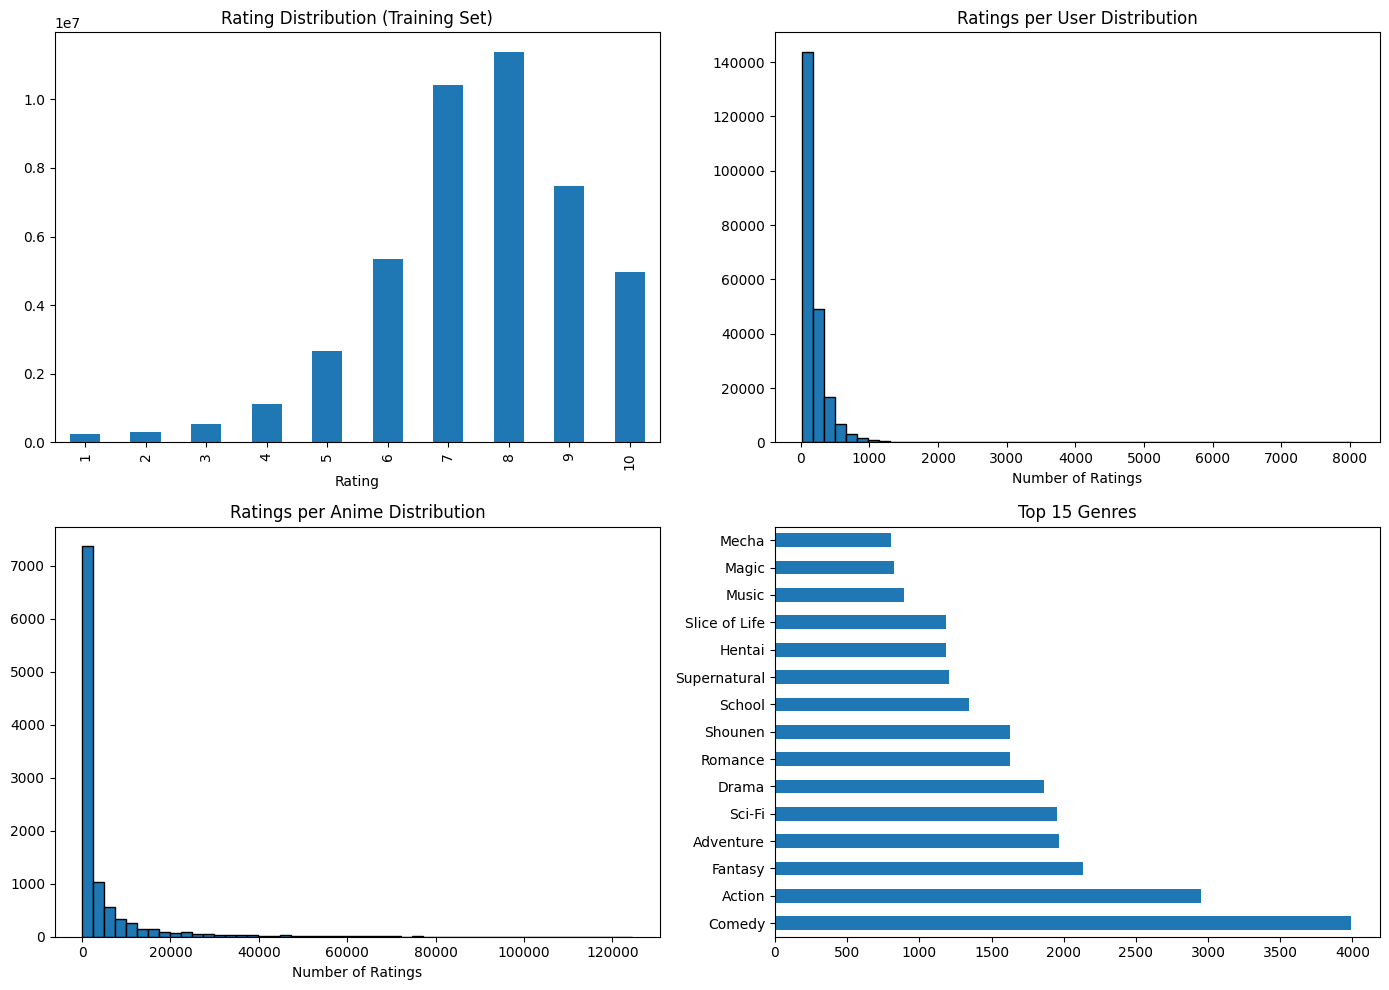

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating distribution
train_df["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Rating Distribution (Training Set)")
axes[0, 0].set_xlabel("Rating")

# User rating count distribution
user_rating_counts = train_df["user_id"].value_counts()
axes[0, 1].hist(user_rating_counts, bins=50, edgecolor="black")
axes[0, 1].set_title("Ratings per User Distribution")
axes[0, 1].set_xlabel("Number of Ratings")

# Anime rating count distribution
anime_rating_counts = train_df["anime_id"].value_counts()
axes[1, 0].hist(anime_rating_counts, bins=50, edgecolor="black")
axes[1, 0].set_title("Ratings per Anime Distribution")
axes[1, 0].set_xlabel("Number of Ratings")

# Top genres
from collections import Counter

all_genres = []
for g in anime_meta_feat["genre_list"]:
    all_genres.extend(g)
genre_counts = Counter(all_genres).most_common(15)
pd.Series(dict(genre_counts)).plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Top 15 Genres")

plt.tight_layout()
plt.savefig("processed/eda.png", dpi=120)
plt.show()